# Transformers: character-level language model
## Yoav Ram

We will see here the [**Transformer** architecture](https://en.wikipedia.org/wiki/Transformer_(deep_learning_architecture)).
Transformers are the basis of large language models like [GPT](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer)--the "T" stands for "Transformer".

Here, we apply transformers to the same problem we applied RNN and GRU: text generation by pretraining a character level model.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # jax compiler messages
os.environ["GRPC_VERBOSITY"] = "ERROR"  # if gRPC noise too
# os.environ['JAX_PLATFORMS'] = 'cpu' # force cpu

import jax
import jax.numpy as jnp
print('jax', jax.__version__, jax.default_backend())
import optax
import numpy as np          # real NumPy, for the data pipeline; jnp is JAX

import glob
import hashlib
import json
import pickle
import time

jax 0.9.2 gpu


# Data: the shared experiment

Like `GRU.ipynb`, this notebook does **not** define its own data. `RNN.ipynb` defines the experiment all three character-level notebooks share and writes it out; we load it.

This matters most here. A transformer has no hidden state to carry between windows, so the shared `state_policy` is `'none'` — every window starts cold, for every model. The earlier version of this comparison streamed the whole corpus through the RNN and GRU while giving the transformer short windows from a zero context, and then reported the three losses side by side. That is a difference in protocol, not in architecture.

If the artifacts are missing, the cell below **fails loudly** rather than re-deriving a split of its own.

In [2]:
SPLIT_PATH = 'checkpoints/charlm_split.npz'
CONFIG_PATH = 'checkpoints/charlm_config.json'

for path in (SPLIT_PATH, CONFIG_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} is missing. Run RNN.ipynb first: it defines the shared '
            'experiment (split, budget, state policy, seed) that this notebook '
            'must reproduce exactly for the comparison to mean anything.')

with open(CONFIG_PATH) as f:
    CONFIG = json.load(f)

split = np.load(SPLIT_PATH, allow_pickle=False)
train_tokens, val_tokens = split['train'], split['val']
chars = [str(c) for c in split['vocab']]
vocab_size = len(chars)
int_to_char = dict(enumerate(chars))
char_to_int = {c: i for i, c in int_to_char.items()}

def array_hash(a):
    return hashlib.sha256(np.ascontiguousarray(a).tobytes()).hexdigest()[:16]

if array_hash(val_tokens) != CONFIG['val_hash']:
    raise ValueError(
        'charlm_split.npz and charlm_config.json disagree: the validation array '
        f"hashes to {array_hash(val_tokens)} but the config records "
        f"{CONFIG['val_hash']}. Re-run RNN.ipynb to regenerate both together.")

print(f"corpus {CONFIG['corpus']}  |  vocabulary {vocab_size}")
print(f"train {len(train_tokens):,} characters  |  val {len(val_tokens):,}  "
      f"|  val_hash {CONFIG['val_hash']}")
print(f"context {CONFIG['context_length']}  |  batch {CONFIG['batch_size']}  "
      f"|  steps {CONFIG['steps']:,}  |  state_policy {CONFIG['state_policy']}  "
      f"|  seed {CONFIG['seed']}")

corpus data/shakespear3.txt  |  vocabulary 67
train 4,116,005 characters  |  val 457,333  |  val_hash b73fdb99e3a24d33
context 128  |  batch 64  |  steps 30,000  |  state_policy none  |  seed 42


The split arrives already encoded as integers, one `uint8` per character. The helpers below are this notebook's own copies of the sampler, the bits-per-character metric and the evaluator — identical in behaviour to the ones in `RNN.ipynb` and `GRU.ipynb`, and checked against the same uniform-model assertion.

In [3]:
def decode(ids):
    return ''.join(int_to_char[int(i)] for i in ids)

def sample_batch(rng, tokens, batch_size, context_length):
    """Draw a batch of random windows. Returns (inputs, targets), both (B, T)."""
    hi = len(tokens) - context_length - 1
    start = rng.integers(0, hi, size=batch_size)
    idx = start[:, None] + np.arange(context_length + 1)[None, :]
    window = tokens[idx]
    return window[:, :-1].astype(np.int32), window[:, 1:].astype(np.int32)

def bits_per_char(total_nats, n_chars):
    return total_nats / n_chars / np.log(2)

def windows(tokens, context_length):
    n = (len(tokens) - 1) // context_length
    idx = np.arange(n * context_length).reshape(n, context_length)
    return tokens[idx].astype(np.int32), tokens[idx + 1].astype(np.int32)

def evaluate_bpc(logprob_fn, tokens, context_length, batch_size=64):
    """Mean bits per character, scored on the same windows as every other model,
    with nothing carried between windows (state_policy='none')."""
    x, y = windows(tokens, context_length)
    total_nats, n = 0.0, 0
    for i in range(0, len(x), batch_size):
        xb, yb = x[i:i + batch_size], y[i:i + batch_size]
        logp = np.asarray(logprob_fn(xb))
        picked = np.take_along_axis(logp, yb[:, :, None], axis=-1)[:, :, 0]
        total_nats += -picked.sum()
        n += picked.size
    return bits_per_char(total_nats, n)

def repeat_seeds(init_fn, logit_fn, first_bpc):
    """One run is not a measurement. Re-train at the remaining seeds in
    CONFIG['seeds'] and return every bits-per-character, so the table can
    report a mean and a spread instead of a single lucky number."""
    out = [float(first_bpc)]
    for seed in CONFIG['seeds'][1:]:
        p = init_fn(seed)
        def loss(p, x, y):
            return -jnp.take_along_axis(jax.nn.log_softmax(logit_fn(p, x)),
                                        y[..., None], axis=-1).mean()
        sch = optax.warmup_cosine_decay_schedule(
            init_value=CONFIG['init_lr'], peak_value=CONFIG['peak_lr'],
            warmup_steps=CONFIG['warmup_steps'], decay_steps=CONFIG['steps'])
        opt = optax.chain(optax.clip_by_global_norm(CONFIG['grad_clip']),
                          optax.adam(learning_rate=sch))
        st = opt.init(p)
        bp = jax.value_and_grad(loss)

        @jax.jit
        def one_step(p, st, x, y):
            l, g = bp(p, x, y)
            u, st = opt.update(g, st, p)
            return optax.apply_updates(p, u), st, l

        r = np.random.default_rng(seed)
        for _ in range(CONFIG['steps']):
            x, y = sample_batch(r, train_tokens, CONFIG['batch_size'],
                                CONFIG['context_length'])
            p, st, _ = one_step(p, st, jnp.asarray(x), jnp.asarray(y))
        lp = jax.jit(lambda i: jax.nn.log_softmax(logit_fn(p, i)))
        out.append(evaluate_bpc(lambda a: lp(jnp.asarray(a)), val_tokens,
                                CONFIG['context_length']))
        print(f'  seed {seed}: {out[-1]:.4f} bpc')
    return out

# How far a model may sit from the shared budget and still count as
# capacity-controlled. The same 6% the cluster runner uses
# (`cluster/charlm_run.py`), and it has to be this loose: the transformer's
# `d_model` must divide by the head count, so the width solver cannot land on
# the budget exactly. It overshoots to 206,635 at 3 blocks (+3.3%) and 209,939
# at 6 (+5.0%), while the recurrent models sit inside 0.5%. A tighter bound here
# would fail runs the experiment was designed to allow.
BUDGET_TOL = 0.06

def in_budget(n_params):
    """Assert a model is within BUDGET_TOL of the shared parameter budget."""
    off = n_params / CONFIG['param_budget'] - 1
    assert abs(off) < BUDGET_TOL, (
        f"{n_params:,} parameters is {off:+.1%} off the shared budget "
        f"{CONFIG['param_budget']:,}: the comparison would not be capacity-controlled")
    return n_params

def write_result(model, bpcs, n_params=None, seconds=None, **extra):
    """Record one row of the comparison, with the experiment it ran under.

    `source` records which machine produced the row. The committed results come
    from the cluster sweep in runs.md C4; running this notebook replaces them
    with your own, and the table prints the column so you can see that it did."""
    a = np.asarray(bpcs, dtype=float)
    record = {'model': model, 'bpc': float(a.mean()),
              'bpc_sd': float(a.std(ddof=1)) if a.size > 1 else 0.0,
              'bpc_seeds': [float(v) for v in a], 'n_params': n_params,
              'seconds': None if seconds is None else round(float(seconds), 1),
              'manifest': dict(CONFIG),
              'source': f'this notebook, {jax.devices()[0].device_kind}', **extra}
    with open(f'checkpoints/charlm_result_{model}.json', 'w') as f:
        json.dump(record, f, indent=2)
    return record

# the evaluator must reproduce the known answer for a uniform model
uniform = lambda x: np.full(x.shape + (vocab_size,), -np.log(vocab_size))
assert np.isclose(evaluate_bpc(uniform, val_tokens, CONFIG['context_length']),
                  np.log2(vocab_size))
print('evaluator agrees with log2(V) on a uniform model')

evaluator agrees with log2(V) on a uniform model


# Text transformer
Unlike RNN and GRU which process sequences step by step maintaining a hidden state, the Transformer processes the entire sequence at once using **self-attention** — each position can directly attend to all previous positions.

## Self-attention

For each position $i$ in the input sequence $x$, we compute **query**, **key**, and **value** vectors:
$$
q_i = W^q x_i, \quad k_j = W^k x_j, \quad v_j = W^v x_j
$$

The **attention weight** of position $i$ to position $j$ is:
$$
w_{ij} = \text{softmax}_j\left(\frac{q_i \cdot k_j}{\sqrt{d_k}}\right)
$$

The output for position $i$ is a weighted sum of values: $z_i = \sum_j w_{ij} v_j$.

A **causal mask** ensures position $i$ only attends to $j \le i$, preserving the autoregressive property (just as in RNN/GRU, character $i$ depends on $j < i$ but not $j > i$).

In **multi-head** attention, we split $q$, $k$, $v$ into multiple heads that attend independently, then concatenate their outputs. This allows the model to attend to different types of relationships simultaneously.


In [4]:
def self_attention(x, W_q, W_k, W_v, W_o, n_heads):
    seq_len, d_model = x.shape
    d_head = d_model // n_heads
    
    Q = x @ W_q  # (seq_len, d_model)
    K = x @ W_k
    V = x @ W_v
    
    # reshape to (n_heads, seq_len, d_head) - no batch dimension
    Q = Q.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    K = K.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    V = V.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    
    # attention weights
    w_logits = (Q @ K.transpose(0, 2, 1)) / jnp.sqrt(d_head)  # (n_heads, seq_len, seq_len)
    # causal mask
    mask = jnp.tril(jnp.ones((seq_len, seq_len)))
    w_logits = w_logits - 1e10 * (1 - mask)
    w = jax.nn.softmax(w_logits, axis=-1)
    
    # weighted sum of values
    z = w @ V  # (n_heads, seq_len, d_head)
    # concatenate heads
    z = z.transpose(1, 0, 2).reshape(seq_len, d_model)
    
    return z @ W_o

## Transfomer blocks

Each transformer block applies:
1. Layer normalization → multi-head self-attention → residual connection
2. Layer normalization → feed-forward network → residual connection

In [5]:
def layer_norm(x, eps=1e-6):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.mean((x - mean) ** 2, axis=-1, keepdims=True)
    return (x - mean) / jnp.sqrt(var + eps)

In [6]:
def transformer_block(x, params, n_heads):
    # self-attention with pre-norm and residual
    x_norm = layer_norm(x)
    x = x + self_attention(x_norm, params['W_q'], params['W_k'],  params['W_v'], params['W_o'], n_heads)
    # feed-forward network with pre-norm and residual connection
    x_norm = layer_norm(x)
    h = jax.nn.relu(x_norm @ params['W1'] + params['b1'])
    x = x + h @ params['W2'] + params['b2']
    return x

def init_layer_params(key, d_model, d_ff):
    keys = jax.random.split(key, 6)
    return {
        'W_q': jax.random.normal(keys[0], (d_model, d_model)) * 0.02,
        'W_k': jax.random.normal(keys[1], (d_model, d_model)) * 0.02,
        'W_v': jax.random.normal(keys[2], (d_model, d_model)) * 0.02,
        'W_o': jax.random.normal(keys[3], (d_model, d_model)) * 0.02,
        'W1': jax.random.normal(keys[4], (d_model, d_ff)) * 0.02,
        'b1': jnp.zeros((d_ff,)),
        'W2': jax.random.normal(keys[5], (d_ff, d_model)) * 0.02,
        'b2': jnp.zeros((d_model,)),
    }


## Transformer classifier

The full model stacks transformer blocks. Unlike RNN and GRU, where the input weight matrix $W_x^h$ implicitly serves as an embedding (since $W_x^h\,\text{onehot}(c)$ selects column $c$), the transformer has no per-step input matrix — it applies the same computation to every position. It therefore needs an explicit **learned token embedding**, which is the *same operation* the RNN writes as `Wxh[:, x_id]`, just named differently.

It also needs a **learned positional embedding**, because self-attention is permutation-**equivariant**: permute the input positions and the outputs come out permuted the same way, not unchanged. (Invariance would mean the output does not move at all — that is what `sets.ipynb` builds, and it is exactly what a language model must *not* have.) Attention alone therefore has no notion of order, and the position embedding supplies it.

### We build one block first, then three

An earlier version of this notebook stacked **5 blocks** while the RNN and GRU each had a single recurrent layer, so the transformer was both larger and five times deeper. That table could not distinguish "attention beats recurrence" from "deep beats shallow".

So we do what the other two notebooks do: build **one block**, train it at the shared parameter budget, and put it in the table next to the one-layer RNN and GRU. Then stack **three**, re-solving the width so the budget still holds, and put that in too. Depth stops being a confound and becomes the measurement — and as it turns out, the difference between how the three architectures respond to depth is the most interesting thing in the whole comparison.

In [7]:
def transformer_model(params, ids, n_heads):
    """One window. ids (T,) of ints -> logits (T, V)."""
    seq_len = ids.shape[0]
    # token embedding + positional embedding.
    # token_emb[ids] is the same column lookup the RNN writes as Wxh[:, x_id]:
    # an embedding table IS the input weight matrix of a one-hot model.
    x = params['token_emb'][ids] + params['pos_emb'][:seq_len]
    for layer_params in params['layers']:
        x = transformer_block(x, layer_params, n_heads)
    # final layer norm and classifier head that outputs logits
    x = layer_norm(x)
    return x @ params['W_out'] + params['b_out']

def batched_logits(params, ids):
    """(B, T) of ints -> (B, T, V) logits.

    The transformer has no state to carry, so every window is cold by
    construction — which is why state_policy='none' is the only policy all three
    architectures in this comparison can implement."""
    return jax.vmap(transformer_model, in_axes=(None, 0, None))(params, ids, n_heads)

def init_params(key, vocab_size, seq_length, d_model, d_ff, n_layers):
    keys = jax.random.split(key, n_layers + 3)
    return {
        'token_emb': jax.random.normal(keys[0], (vocab_size, d_model)) * 0.02,
        'pos_emb': jax.random.normal(keys[1], (seq_length, d_model)) * 0.02,
        'layers': [init_layer_params(keys[2 + i], d_model, d_ff) for i in range(n_layers)],
        'W_out': jax.random.normal(keys[-1], (d_model, vocab_size)) * 0.02,
        'b_out': jnp.zeros((vocab_size,)),
    }

# Loss function

The loss function is categorical cross-entropy (negative log-likelihood).
We use `log_softmax` for numerical stability.

In [8]:
seq_length = CONFIG['context_length']
d_model = CONFIG['tf_d_model']
d_ff = CONFIG['tf_d_ff']
n_heads = CONFIG['tf_n_heads']
n_layers = CONFIG['tf_n_layers']

key = jax.random.key(0)
params = init_params(key, vocab_size, seq_length, d_model, d_ff, n_layers)

rng = np.random.default_rng(CONFIG['seed'])
xb, yb = sample_batch(rng, train_tokens, CONFIG['batch_size'], CONFIG['context_length'])
xb, yb = jnp.asarray(xb), jnp.asarray(yb)

logits = batched_logits(params, xb)
assert logits.shape == (CONFIG['batch_size'], seq_length, vocab_size)
print('batch of windows ->', logits.shape, '(batch, time, vocab)')

batch of windows -> (64, 128, 67) (batch, time, vocab)


The NLL (negative log-likelihood, cross-entropy) for a single step is
$$
NLL = -\sum_{k=0}^{V}{x_{t+1,k} \log{\hat{y}_{t,k}}}
$$
where $k$ runs over all $V$ characters.
The total NLL is computed by averaging over all positions $t$.

In [9]:
def NLL(params, x, y):
    """Mean negative log-likelihood per character. x, y are (B, T) integer arrays."""
    logp = jax.nn.log_softmax(batched_logits(params, x))      # (B, T, V)
    return -jnp.take_along_axis(logp, y[..., None], axis=-1).mean()

# untrained, the model knows nothing, so the loss should sit at log(V)
loss = NLL(params, xb, yb)
print(f'untrained loss {float(loss):.4f} nats   (log(V) = {np.log(vocab_size):.4f})')

untrained loss 4.2548 nats   (log(V) = 4.2047)


## Automatic differentiation with JAX

We use JAX's automatic differentiation to compute gradients. [`jax.value_and_grad`](https://jax.readthedocs.io/en/latest/jax-101/01-jax-basics.html#value-and-grad) returns both the loss value and the gradient of the loss with respect to the parameters.

In [10]:
backprop = jax.value_and_grad(NLL)

loss, grads = backprop(params, xb, yb)
for k in params:
    if k == 'layers':
        for layer_params, layer_grads in zip(params[k], grads[k]):
            for p_name in layer_params:
                assert layer_params[p_name].shape == layer_grads[p_name].shape
    else:
        assert params[k].shape == grads[k].shape
print('gradient shapes match the parameters')

gradient shapes match the parameters


# Adam optimizer with Optax

We can use a JAX implementation of the Adam optimizer from the [Optax](https://optax.readthedocs.io/) library.
We first create the optimizer and initialize its state.

In [11]:
optimizer = optax.adam(learning_rate=0.001) # 0.001 is the default from Kingma et al 2014
opt_state = optimizer.init(params)

We then use the optimizer to compute the updates, and apply them.

In [12]:
loss, grads = backprop(params, xb, yb)
updates, opt_state = optimizer.update(grads, opt_state, params)
params = optax.apply_updates(params, updates)

# JITing the training step

We write a function that does all this, and pass it to `jax.jit`, which [just-in-time compiles the function](https://jax.readthedocs.io/en/latest/jax-101/02-jitting.html) so it can be executed efficiently in XLA.

In [13]:
@jax.jit
def update_params(params, opt_state, x, y):
    loss, grads = backprop(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [14]:
%timeit update_params(params, opt_state, xb, yb)[2].block_until_ready()

3.61 ms ± 30.3 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [15]:
params, opt_state, loss = update_params(params, opt_state, xb, yb)
print(loss)
params, opt_state, loss = update_params(params, opt_state, xb, yb)
print(loss)

3.8880115
3.7334695


# Sampling from the network

Unlike RNN and GRU, which carry a hidden state, the transformer must re-process its whole context at every step, so sampling is inherently more expensive.

There is a trap here that costs more than the quadratic attention does. The obvious loop feeds the model exactly the characters generated so far, so the context grows by one every step — and `jax.jit` compiles a **separate kernel for every distinct input shape**. Generating 500 characters that way triggers hundreds of compilations, and the sampler takes longer than the entire training run. An earlier version of this notebook did exactly that.

The fix is to keep the shape fixed: a buffer of `seq_length` characters, written in place, with the logits read at the position of the last real character. The causal mask already prevents later positions from influencing an earlier one, so the unused tail of the buffer is inert. One shape, one compile.

(A KV cache would go further, reusing the keys and values of positions that have not changed — that is what makes production inference cheap, and it is left as an exercise.)

In [16]:
@jax.jit
def next_logits(params, buf, n):
    """Logits following position n-1 of a fixed-size buffer. One shape, one compile."""
    return transformer_model(params, buf, n_heads)[n - 1]

def sample(params, num_samples, key, prompt=None, temperature=1.0):
    """Generate text with a fixed-shape context buffer."""
    if prompt:
        ids = [char_to_int[c] for c in prompt][-seq_length:]
    else:
        key, subkey = jax.random.split(key)
        ids = [int(jax.random.choice(subkey, vocab_size))]
    out = list(ids)

    buf = jnp.zeros(seq_length, dtype=jnp.int32).at[:len(ids)].set(jnp.array(ids))
    n = len(ids)

    for _ in range(num_samples - len(ids)):
        logits = next_logits(params, buf, n)
        key, subkey = jax.random.split(key)
        tok = int(jax.random.categorical(subkey, logits / temperature))
        out.append(tok)
        if n < seq_length:
            buf = buf.at[n].set(tok)
            n += 1
        else:                       # window full: slide it along
            buf = jnp.concatenate([buf[1:], jnp.array([tok])])

    return decode(out)

print(sample(params, 100, jax.random.key(1)))

Go]t$o' aI.gshnlKQey
UcAreeXqHQ a$d'Q !t'SaLyIlweOtL3b$Oet3NvCT:RmaY]IypBK'Ag?u;F'oS?v
USfMZB:jMAO$l


# Training the network

We setup the training - the sequence length, the number of batches, parameter initialization, Adam optimizer.

In [17]:
key = jax.random.key(CONFIG['seed'])
rng = np.random.default_rng(CONFIG['seed'])

seq_length = CONFIG['context_length']
d_model = CONFIG['tf_d_model']
d_ff = CONFIG['tf_d_ff']
n_heads = CONFIG['tf_n_heads']
n_layers = CONFIG['tf_n_layers']

params = init_params(key, vocab_size, seq_length, d_model, d_ff, n_layers)

backprop = jax.value_and_grad(NLL)

# Warmup + cosine decay over the full budget, with gradient clipping.
# Same schedule as RNN.ipynb and GRU.ipynb: the learning rate is part of the
# shared experiment, not a per-model tuning knob.
schedule = optax.warmup_cosine_decay_schedule(
    init_value=CONFIG['init_lr'],
    peak_value=CONFIG['peak_lr'],
    warmup_steps=CONFIG['warmup_steps'],
    decay_steps=CONFIG['steps'],
)
optimizer = optax.chain(
    optax.clip_by_global_norm(CONFIG['grad_clip']),
    optax.adam(learning_rate=schedule),
)
opt_state = optimizer.init(params)

# rebuilt because it closes over `optimizer` and `backprop`, rebound just above
@jax.jit
def update_params(params, opt_state, x, y):
    loss, grads = backprop(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

os.makedirs('checkpoints/charlm', exist_ok=True)
train_losses, val_losses = [], []
print(f"{CONFIG['steps']:,} steps of {CONFIG['batch_size']} x "
      f"{CONFIG['context_length']} characters")

30,000 steps of 64 x 128 characters


Now we can train the Transformer!

In [18]:
%%time
_t0 = time.time()
report_every = CONFIG['steps'] // 10
check_every = CONFIG['steps'] // 50

for batch in range(CONFIG['steps']):        # exactly `steps` updates, no early stopping
    x, y = sample_batch(rng, train_tokens, CONFIG['batch_size'], CONFIG['context_length'])
    params, opt_state, loss = update_params(params, opt_state, jnp.asarray(x), jnp.asarray(y))
    train_losses.append((batch, float(loss)))

    if batch % check_every == 0:
        vx, vy = sample_batch(np.random.default_rng(0), val_tokens,
                              CONFIG['batch_size'], CONFIG['context_length'])
        val_losses.append((batch, float(NLL(params, jnp.asarray(vx), jnp.asarray(vy)))))

    if batch % report_every == 0:
        print(f'step {batch:6d}  train {float(loss):.4f}  val {val_losses[-1][1]:.4f} nats')
        with open(f'checkpoints/charlm/transformer-{batch}.pkl', 'wb') as file:
            pickle.dump(params, file)

with open(f"checkpoints/charlm/transformer-{CONFIG['steps']}.pkl", 'wb') as file:
    pickle.dump(params, file)
train_seconds = time.time() - _t0
print(f"\nfinal train loss {train_losses[-1][1]:.4f} nats in {train_seconds/60:.1f} min")

step      0  train 4.2138  val 4.1618 nats


step   3000  train 1.5090  val 1.6035 nats


step   6000  train 1.4528  val 1.5617 nats


step   9000  train 1.4641  val 1.5483 nats


step  12000  train 1.4225  val 1.5394 nats


...

step  18000  train 1.3980  val 1.5088 nats


step  21000  train 1.3853  val 1.4955 nats


step  24000  train 1.3833  val 1.4902 nats


step  27000  train 1.3524  val 1.4839 nats



final train loss 1.3677 nats in 2.9 min
CPU times: user 1min 2s, sys: 14.9 s, total: 1min 17s
Wall time: 2min 56s


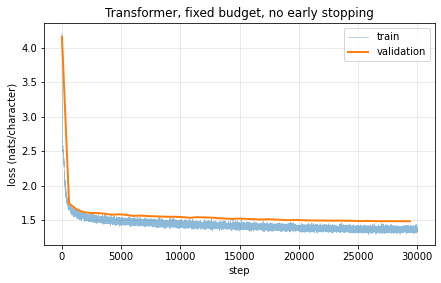

In [19]:
# dpi 72 rather than the default 100: the inline PNG of a 30,000-point curve is
# 42 KB of base64 at dpi 100 and 27 KB at 72, and the notebook has to stay under
# the editor's read limit to remain editable after it has been run (CLAUDE.md).
fig, ax = plt.subplots(figsize=(7, 4), dpi=72)
ax.plot(*zip(*train_losses), lw=0.6, alpha=0.5, label='train')
ax.plot(*zip(*val_losses), lw=2, label='validation')
ax.set_xlabel('step'); ax.set_ylabel('loss (nats/character)')
ax.set_title('Transformer, fixed budget, no early stopping')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# Load parameters from specific batch

In [20]:
# Sort by step number, not lexicographically: sorted() on the raw paths puts
# '-9000.pkl' after '-10000.pkl' and would load the wrong checkpoint.
paths = sorted(glob.glob("checkpoints/charlm/transformer-*.pkl"),
               key=lambda p: int(p.rsplit('-', 1)[1].removesuffix('.pkl')))
if not paths:
    raise FileNotFoundError("No Transformer checkpoint files found in checkpoints/")

latest = paths[-1]
print("Loading checkpoint:", latest)
with open(latest, 'rb') as file:
    params = pickle.load(file)

Loading checkpoint: checkpoints/charlm/transformer-30000.pkl


In [21]:
print(sample(params, 500, jax.random.key(21), prompt='ROMEO:'))

ROMEO:
To shall, it dastill the tell our ancient.

FERDINAND:

MOPSOLINUS:
By God all it them be skill his made:
Live, your grarity: but one of your day.

ACHILLES:
Aress imine be lawfuurse my dissue,
Whether hand threated by my masters vantagmence,
Denied: just, read is on the corse given's exellent tempested same! O break 't foul Francis,
Which and might that virtue to be, an you shalt your with conspirate
Of sorrow me of
Would did of death, great your unes:
His wrink of Titanian, to shall not


# Scoring the trained model

Same evaluator, same windows, same cold start as the baselines, the RNN and the GRU — then write the transformer's row of the comparison.

In [22]:
tf_logprob = jax.jit(lambda ids: jax.nn.log_softmax(batched_logits(params, ids)))

tf_bpc = evaluate_bpc(lambda x: tf_logprob(jnp.asarray(x)),
                      val_tokens, CONFIG['context_length'])
n_params = in_budget(sum(a.size for a in jax.tree_util.tree_leaves(params)))

tf_bpcs = repeat_seeds(
    lambda s: init_params(jax.random.key(s), vocab_size, seq_length, d_model, d_ff, n_layers),
    batched_logits, tf_bpc)
write_result('transformer', tf_bpcs, n_params=n_params, seconds=train_seconds)
print(f'Transformer  {np.mean(tf_bpcs):.3f} bpc   ({n_params:,} parameters)')

  seed 43: 2.1850 bpc


  seed 44: 2.1883 bpc
Transformer  2.185 bpc   (204,907 parameters)


# Stacking blocks

The same question the other two notebooks ask, and the one this architecture was built for: hold the parameter budget fixed and spend it on depth instead of width.

| | 1 block | 3 blocks |
|---|---|---|
| `d_model` | 120 | 72 |
| `d_ff` | 480 | 288 |
| parameters | ~205 k | ~207 k |

Nothing in the code changes — `transformer_model` already loops over `params['layers']`, so a deeper model is a different `n_layers` and nothing else. That is worth noticing on its own: stacking a transformer is free in code, and the earlier notebooks had to write a genuinely new model to stack a recurrent cell.

It is close to free in *training* too, and this is the point the architecture was designed around. Three blocks is three times the arithmetic, but not three times the **sequential** depth: each block still processes all 128 positions at once, so the GPU sees three big matmuls instead of one. A three-layer recurrent stack, by contrast, turns 128 sequential steps into 384 — and a GPU cannot parallelise across a dependency chain.

That is the cost asymmetry that decides everything below: for the transformer, depth is cheap. For a recurrent stack, depth is the one thing that is expensive.

So the prediction is that depth is a better buy here than it was for the RNN or the GRU. The table below says whether it was.

In [23]:
%%time
_d0 = time.time()
deep_d = CONFIG['tf_d_model_3l']
deep_ff = CONFIG['tf_d_ff_3l']
n_deep = CONFIG['n_layers_deep']

deep_params = init_params(jax.random.key(CONFIG['seed']), vocab_size, seq_length,
                          deep_d, deep_ff, n_deep)
print(f"{n_deep} blocks, d_model={deep_d}: "
      f"{sum(a.size for a in jax.tree_util.tree_leaves(deep_params)):,} parameters "
      f"(1 block, d_model={CONFIG['tf_d_model']}: {n_params:,})")

def deep_NLL(p, x, y):
    logits = jax.vmap(transformer_model, in_axes=(None, 0, None))(p, x, n_heads)
    logp = jax.nn.log_softmax(logits)
    return -jnp.take_along_axis(logp, y[..., None], axis=-1).mean()

deep_backprop = jax.value_and_grad(deep_NLL)
deep_sched = optax.warmup_cosine_decay_schedule(
    init_value=CONFIG['init_lr'], peak_value=CONFIG['peak_lr'],
    warmup_steps=CONFIG['warmup_steps'], decay_steps=CONFIG['steps'])
deep_opt = optax.chain(optax.clip_by_global_norm(CONFIG['grad_clip']),
                       optax.adam(learning_rate=deep_sched))
deep_state = deep_opt.init(deep_params)

@jax.jit
def deep_update(p, s, x, y):
    l, g = deep_backprop(p, x, y)
    u, s = deep_opt.update(g, s, p)
    return optax.apply_updates(p, u), s, l

deep_rng = np.random.default_rng(CONFIG['seed'])
deep_train, deep_val = [], []
for batch in range(CONFIG['steps']):
    x, y = sample_batch(deep_rng, train_tokens, CONFIG['batch_size'], CONFIG['context_length'])
    deep_params, deep_state, loss = deep_update(deep_params, deep_state,
                                                jnp.asarray(x), jnp.asarray(y))
    deep_train.append((batch, float(loss)))
    if batch % (CONFIG['steps'] // 50) == 0:
        vx, vy = sample_batch(np.random.default_rng(0), val_tokens,
                              CONFIG['batch_size'], CONFIG['context_length'])
        deep_val.append((batch, float(deep_NLL(deep_params, jnp.asarray(vx), jnp.asarray(vy)))))
    if batch % (CONFIG['steps'] // 10) == 0:
        print(f'step {batch:6d}  train {float(loss):.4f}  val {deep_val[-1][1]:.4f} nats')

with open(f"checkpoints/charlm/transformer3l-{CONFIG['steps']}.pkl", 'wb') as file:
    pickle.dump(deep_params, file)
deep_seconds = time.time() - _d0
print(f"\nfinal train loss {deep_train[-1][1]:.4f} nats in {deep_seconds/60:.1f} min")

3 blocks, d_model=72: 206,635 parameters (1 block, d_model=120: 204,907)


step      0  train 4.2239  val 4.1787 nats


step   3000  train 1.4440  val 1.5186 nats


step   6000  train 1.3724  val 1.4727 nats


step   9000  train 1.3569  val 1.4508 nats


...

step  18000  train 1.2896  val 1.4248 nats


step  21000  train 1.2763  val 1.4233 nats


step  24000  train 1.2595  val 1.4191 nats


step  27000  train 1.2379  val 1.4123 nats



final train loss 1.2610 nats in 4.5 min
CPU times: user 2min 32s, sys: 16.1 s, total: 2min 49s
Wall time: 4min 28s


In [24]:
deep_logprob = jax.jit(lambda ids: jax.nn.log_softmax(
    jax.vmap(transformer_model, in_axes=(None, 0, None))(deep_params, ids, n_heads)))

deep_bpc = evaluate_bpc(lambda x: deep_logprob(jnp.asarray(x)),
                        val_tokens, CONFIG['context_length'])
deep_n = in_budget(sum(a.size for a in jax.tree_util.tree_leaves(deep_params)))

deep_logit = lambda p, i: jax.vmap(transformer_model, in_axes=(None, 0, None))(p, i, n_heads)
deep_bpcs = repeat_seeds(
    lambda s: init_params(jax.random.key(s), vocab_size, seq_length, deep_d, deep_ff, n_deep),
    deep_logit, deep_bpc)
write_result('transformer-3L', deep_bpcs, n_params=deep_n, seconds=deep_seconds)

print(f"{'Transformer, 1 block  d=' + str(CONFIG['tf_d_model']):<30} {np.mean(tf_bpcs):.3f} bpc  "
      f"{n_params:>8,} params  {train_seconds/60:.1f} min")
print(f"{'Transformer, 3 blocks d=' + str(CONFIG['tf_d_model_3l']):<30} {np.mean(deep_bpcs):.3f} bpc  "
      f"{deep_n:>8,} params  {deep_seconds/60:.1f} min")
print()
print(f"depth bought {np.mean(tf_bpcs) - np.mean(deep_bpcs):+.3f} bpc "
      f"({'better' if np.mean(deep_bpcs) < np.mean(tf_bpcs) else 'worse'}) for the same parameters")

  seed 43: 2.0370 bpc


  seed 44: 2.0350 bpc
Transformer, 1 block  d=120    2.185 bpc   204,907 params  2.9 min
Transformer, 3 blocks d=72     2.043 bpc   206,635 params  4.5 min

depth bought +0.142 bpc (better) for the same parameters


# Results so far

The last notebook in the sequence, so this table is the complete comparison — provided you have run `RNN.ipynb` and `GRU.ipynb`. Any model you have not run is named as `not run` rather than omitted, and a row produced under a different experiment is marked `stale` rather than quietly compared against the rest.

Read it with the state policy in mind: all three models were trained and scored on cold 128-character windows, which is the only protocol a transformer can implement, and which costs the recurrent models the long-range context they would normally carry.

The second table is the same measurement along the depth axis. Depths 1 and 3 are the rows above; depths 2, 4 and 6 are 27 further trainings from the cluster sweep logged in `runs.md` C5, read from `checkpoints/charlm-depth/`. The discussion that follows quotes those numbers, so they are printed from the files rather than typed into the text — and the `from` column says which machine produced each row, since re-running the training cells above overwrites the committed cluster results with your own.

**Check the `from` column before reading the minutes.** Bits per character is a property of the model and is comparable across machines; wall-clock is not. As soon as some rows say `notebook` and others say `cluster`, the minutes column mixes your GPU with the cluster's A6000 and cannot be read straight down — a depth-1 row you trained yourself can look *slower* than a depth-2 row from the cluster. The cost argument below rests on ratios **within** one machine; take them from rows whose `from` column agrees.

In [25]:
EXPECTED_MODELS = ['unigram', 'bigram', 'rnn', 'rnn-3L', 'gru', 'gru-3L',
                   'transformer', 'transformer-3L']
# Everything two rows must agree on before it is fair to compare them. The
# schedule is in the list because exercise 2 sweeps `peak_lr`: a swept row has
# every other control untouched, so without these keys it would sit in the table
# looking like a like-for-like comparison when it is not.
COMPARE_KEYS = ['val_hash', 'state_policy', 'context_length', 'steps',
                'batch_size', 'seeds', 'param_budget',
                'peak_lr', 'init_lr', 'warmup_steps', 'grad_clip']
DEPTH_DIR = 'checkpoints/charlm-depth'

def results_table():
    """Print the comparison from whatever result files exist.

    Rows produced under a different experiment are marked `stale` rather than
    raising: a table that refuses to render teaches nothing, and the rows that
    *are* comparable are still worth seeing. Models never run are named too, so
    the table can never look complete when it is not. The `from` column names
    the machine each row came from, because re-running a training cell above
    silently replaces a committed cluster number with your own."""
    found = {}
    for path in sorted(glob.glob('checkpoints/charlm_result_*.json')):
        with open(path) as f:
            r = json.load(f)
        found[r['model']] = r

    if not found:
        print('No results yet. Run RNN.ipynb first.')
        return

    def signature(r):
        return tuple(str(r['manifest'].get(k)) for k in COMPARE_KEYS)

    def origin(r):
        s = (r.get('source') or '').lower()
        if 'cluster' in s:
            return 'cluster'
        if 'notebook' in s:
            return 'notebook'
        return (r.get('source') or '-')[:12]

    counts = {}
    for r in found.values():
        counts[signature(r)] = counts.get(signature(r), 0) + 1
    current = max(counts, key=counts.get)          # the majority experiment
    ref = next(r for r in found.values() if signature(r) == current)['manifest']

    print(f"corpus {ref['corpus']} | context {ref['context_length']} | "
          f"state_policy {ref['state_policy']} | ~{ref['param_budget']:,} parameters "
          f"per model | seeds {ref['seeds']} (mean +- sd)")
    print()
    print(f"{'model':<14}{'bpc (mean+-sd)':>16}{'params':>11}{'train':>9}  {'from':<12}")
    print('-' * 66)
    stale, sources = [], {}
    for name in EXPECTED_MODELS:
        r = found.get(name)
        if r is None:
            print(f"{name:<14}{'not run':>16}{'':>11}{'':>9}")
        elif signature(r) != current:
            print(f"{name:<14}{'stale':>16}{'':>11}{'':>9}")
            stale.append(name)
        else:
            p = r.get('n_params')
            sec = r.get('seconds')
            sd = r.get('bpc_sd', 0.0)
            if r.get('source'):
                sources.setdefault(origin(r), r['source'])
            print(f"{name:<14}{r['bpc']:>10.3f}+-{sd:<4.3f}{('' if p is None else f'{p:,}'):>11}"
                  f"{('' if sec is None else f'{sec/60:.1f}m'):>9}  {origin(r):<12}")

    if stale:
        print()
        print(f"stale: {', '.join(stale)} ran under a different experiment. "
              'Re-run against the current charlm_config.json.')
    print()
    for short, full in sorted(sources.items()):
        print(f'  {short:<10} {full}')

def depth_table(architectures=('rnn', 'gru', 'transformer')):
    """Print the depth curve, read from the committed per-seed result files.

    Depths 1 and 3 are the rows of the table above. Depths 2, 4 and 6 come from
    `checkpoints/charlm-depth/<model>_<seed>.json` — one file per run, written
    by the cluster array job logged in `runs.md` C5. That sweep is 27 trainings
    and hours of GPU time, so this notebook reads it rather than reproducing it;
    but it *reads* it, instead of having the numbers typed into the discussion
    below, so every figure quoted there can be checked against a file."""
    runs = {}                      # (architecture, depth) -> ([bpc], [seconds])
    def add(arch, depth, bpc, seconds):
        b, s = runs.setdefault((arch, depth), ([], []))
        b.append(bpc)
        if seconds is not None:
            s.append(seconds)

    for arch in architectures:                      # depths 1 and 3
        for name, depth in ((arch, 1), (f'{arch}-3L', 3)):
            path = f'checkpoints/charlm_result_{name}.json'
            if not os.path.exists(path):
                continue
            with open(path) as f:
                r = json.load(f)
            if r['manifest'].get('val_hash') != CONFIG['val_hash']:
                continue                            # a different experiment
            for bpc in r.get('bpc_seeds') or [r['bpc']]:
                add(arch, depth, bpc, r.get('seconds'))

    for path in sorted(glob.glob(f'{DEPTH_DIR}/*.json')):   # depths 2, 4, 6
        with open(path) as f:
            r = json.load(f)
        arch = r['model'].split('-')[0]
        if arch in architectures and r.get('val_hash') == CONFIG['val_hash']:
            add(arch, r['n_layers'], r['bpc'], r.get('seconds'))

    if not runs:
        print(f'No depth runs found. Depths 2/4/6 live in {DEPTH_DIR}/ '
              '(cluster job; see runs.md C5).')
        return

    depths = sorted({d for _, d in runs})
    print('bits per character, mean +- sd over seeds, and minutes per run')
    print(f"{'depth':<6}" + ''.join(f'{a:>24}' for a in architectures))
    print('-' * (6 + 24 * len(architectures)))
    for d in depths:
        row = f'{d:<6}'
        for arch in architectures:
            b, s = runs.get((arch, d), ([], []))
            if not b:
                cell = '--'
            else:
                sd = float(np.std(b, ddof=1)) if len(b) > 1 else 0.0
                mins = f'{np.mean(s) / 60:.1f}m' if s else ''
                cell = f'{np.mean(b):.3f}+-{sd:.3f}  {mins}'
            row += f'{cell:>24}'
        print(row)
    short = [f'{a}-{d}L ({len(b)})' for (a, d), (b, _) in sorted(runs.items())
             if len(b) < len(CONFIG['seeds'])]
    print(f"\neach point is {len(CONFIG['seeds'])} seeds" +
          (f"; fewer for {', '.join(short)}" if short else ''))

results_table()
print()
depth_table()

corpus data/shakespear3.txt | context 128 | state_policy none | ~200,000 parameters per model | seeds [42, 43, 44] (mean +- sd)

model           bpc (mean+-sd)     params    train  from        
------------------------------------------------------------------
unigram            4.770+-0.000                      -           
bigram             3.581+-0.000                      -           
rnn                2.097+-0.007    200,267     4.0m  cluster     
rnn-3L             2.084+-0.006    200,531    11.2m  cluster     
gru                2.061+-0.014    200,141     5.8m  cluster     
gru-3L             2.042+-0.008    201,441    15.7m  cluster     
transformer        2.185+-0.004    204,907     2.9m  notebook    
transformer-3L     2.043+-0.011    206,635     4.5m  notebook    

  cluster    TAU cluster array job 21969289 (RTX A6000); see runs.md C4
  notebook   this notebook, NVIDIA RTX A4000

bits per character, mean +- sd over seeds, and minutes per run
depth                      rn

### How big is a real gap?

Every row above is already a mean over the three seeds in `CONFIG['seeds']`, with its spread in the `+-` column. A spread is only useful if you know what to do with it, so the cell below turns it into a threshold — **two standard deviations**, the rule every claim in the discussion that follows is measured against.

Nothing is retrained to get it. `repeat_seeds` already trained the one-block transformer once per seed to produce `tf_bpcs`; the band is that array's standard deviation. Because three runs estimate a standard deviation poorly, the cell also pools the spreads of the six trained models in the table — eighteen runs is a much better estimate than any single trio. (The two count-based baselines have no seed to vary, so they contribute nothing.)

In the committed runs the pooled figure is about **0.008 bpc**, so the working threshold is about **0.015**: treat any gap smaller than that as noise, no matter how suggestive it looks.

In [26]:
# `tf_bpcs` already holds one bits-per-character per seed for the 1-block
# transformer -- `repeat_seeds` trained it once per seed to produce that array.
# So the noise band is arithmetic on numbers already in scope, not another three
# trainings; re-running them here would cost ~4 minutes to recompute a variable
# we have.
for s, b in zip(CONFIG['seeds'], tf_bpcs):
    print(f'  seed {s}: {b:.4f} bpc')
sd_1block = float(np.std(tf_bpcs, ddof=1))
print(f'\n1-block transformer: mean {np.mean(tf_bpcs):.4f}   '
      f'sd {sd_1block:.4f}   (n = {len(tf_bpcs)})')

# An sd from three runs is itself a noisy number, so pool it over every model in
# the table: same seeds, same schedule, so the seed-to-seed spread is the same
# quantity in each row. Root-mean-square of the per-model sds, which is the
# pooled estimate when every model contributes the same number of runs.
sds = [r['bpc_sd'] for r in (json.load(open(p)) for p in
                             sorted(glob.glob('checkpoints/charlm_result_*.json')))
       if r.get('bpc_sd')]
SD = float(np.sqrt(np.mean(np.square(sds)))) if sds else sd_1block
BAND = 2 * SD
print(f'pooled over {len(sds)} models: sd {SD:.4f} bpc')
print(f'-> treat any gap below 2 sd = {BAND:.3f} bpc as noise')

  seed 42: 2.1807 bpc
  seed 43: 2.1850 bpc
  seed 44: 2.1883 bpc

1-block transformer: mean 2.1847   sd 0.0038   (n = 3)
pooled over 6 models: sd 0.0089 bpc
-> treat any gap below 2 sd = 0.018 bpc as noise


# Why transformers replaced RNNs

The table above does not say that attention models text better than recurrence. Read the one-layer rows: with the same parameters, the same data, the same window and the same schedule, the **GRU wins** — 2.061 bits per character against the transformer's 2.178. The plain RNN beats the transformer too. The one-block transformer is the *worst model in the table*. If quality per parameter at this scale were the whole story, this course would be teaching GRUs.

So the usual slogan — "transformers are better than RNNs" — is false as stated, and this notebook measures it being false. The real argument is about **cost**, and it is the argument the original paper makes.

## The main result: recurrence is sequential, attention is not

[Vaswani et al. (2017)](https://arxiv.org/abs/1706.03762) do not justify self-attention by claiming it is a better model of language. Their Section 4, *Why Self-Attention*, compares layer types on three axes, and the decisive one is **sequential operations** — how many steps must happen strictly one after another to process a sequence of length $n$:

| layer type | complexity per layer | **sequential operations** | max path length |
|---|---|---|---|
| self-attention | $O(n^2 \cdot d)$ | $O(1)$ | $O(1)$ |
| recurrent | $O(n \cdot d^2)$ | $O(n)$ | $O(n)$ |

Read the first column before the second: with $n = 128$ and $d$ in the tens, self-attention does **more arithmetic**, not less. What it does not do is *wait*. A recurrent layer over a 128-character window is 128 steps that must be walked in order, because step $t$ needs $h_{t-1}$. A transformer block is one batched matmul over all 128 positions at once. A GPU has thousands of cores and a dependency chain has no use for them.

That is not a theoretical point here. It is the minutes column of the two tables printed above — the 1- and 3-layer rows are runs this notebook reproduces on your own machine; the 6-layer row is read from the cluster sweep (`runs.md` C5, an RTX A6000), which this notebook does not run:

| | 1 layer | 3 layers | 6 layers |
|---|---|---|---|
| gru | 5.8 min | 15.7 min | 30.9 min |
| rnn | 4.0 min | 11.2 min | 21.5 min |
| transformer | 1.2 min | 2.0 min | **2.9 min** |

Six transformer blocks cost **2.9 minutes**; six GRU layers cost **30.9** — more than ten times as much, for a model that scores *worse*. And the gap widens with depth, because each added transformer block is more parallel arithmetic while each added recurrent layer is 128 more steps on the chain.

**This is the whole argument, and it needs nothing else.** Attention is not cheaper in operations; it is cheaper in *time*, on hardware that rewards parallelism. Everything downstream — that you can afford 12 blocks, then 96, then a budget measured in GPU-years — follows from being able to buy depth at that price.

## The supporting result: depth also buys quality here — but read the caveat

Hold the 200k budget fixed, re-solve the width at each depth, and walk the depth axis. This is the second table printed above, reproduced here without the spreads; every entry is the mean of three seeds:

| depth | rnn | gru | transformer |
|---|---|---|---|
| 1 | 2.097 | 2.061 | 2.178 |
| 2 | 2.087 | **2.028** | 2.072 |
| 3 | **2.084** | 2.042 | 2.044 |
| 4 | 2.163 | 2.079 | 2.069 |
| 6 | 3.343 | 2.291 | **2.041** |

The two recurrent models get *worse* past a point and the transformer does not. Read each curve against the 0.015 noise band before reading anything into it:

- **transformer**: a large gain from 1 to 3 (0.133, seventeen standard deviations), then a wobble — depth 4 is 0.025 *worse* than depth 3, which is outside the band and so not dismissible — and then its best value at 6. Falling overall and still falling at the end, but not monotonically.
- **gru**: best at 2 layers, and every point past 2 is worse; by depth 6 it has given back 0.26, far outside the band.
- **rnn**: flat from 1 to 3 (the 1 → 3 change is 0.012, inside the band — there is no measured peak, only a plateau), then collapse.

And the collapse is not gentle. At depth 6 the individual seeds are:

| | seed 42 | seed 43 | seed 44 | spread |
|---|---|---|---|---|
| rnn-6L | 2.317 | 2.942 | 4.770 | **2.453** |
| gru-6L | 2.184 | 2.289 | 2.401 | 0.217 |
| transformer-6L | 2.038 | 2.040 | 2.046 | **0.008** |

One 6-layer RNN seed in three **fails to train**, landing at 4.77 bpc against a uniform baseline of $\log_2 67 = 6.07$ — barely better than guessing. The transformer's spread is 300× tighter.

> **But this comparison is not clean, and you should not lean on it.** Every transformer block here is wrapped in residual connections — `x = x + attention(...)`, `x = x + mlp(...)` — so a block that has learned nothing passes its input through and the gradient reaches the bottom of the stack along an identity path. Our deep RNN and GRU have no such path: each layer's output *is* the next layer's input. So the right reading of the table above is **"residual stacks train deep and plain stacks do not"**, which is a fact about [He et al. 2015](https://arxiv.org/abs/1512.03385) and layer normalisation as much as about attention. A recurrent net built with skip connections would do considerably better than ours. That is exercise 3, and it is the most interesting experiment left in this notebook.

What the caveat does *not* touch is the section above it. Residual connections are free — they add no parameters and no sequential steps — so a repaired deep GRU would still be 128 sequential steps per layer, and still ten times slower than the transformer at equal depth. **The cost argument survives the confound; the quality argument does not.** That is why they are in this order.

## The conclusion

Put them together and the answer to "which architecture do I take to a larger dataset and a larger compute budget?" is settled, even though the GRU is ahead on this one:

> When we scale up — more data, more compute, more parameters — we want an architecture we can afford to make **deeper**, because depth is where the capability comes from. Recurrence makes depth expensive by construction: every layer adds another chain that must be walked one step at a time. Attention makes it cheap, by doing more arithmetic in fewer sequential steps. **That is the transformer**, and that is why it replaced the RNN.

The GRU's 2.028 is a better number today. But it was bought with 11.9 minutes at the top of a curve that turns downward, and there is nowhere further to go. The transformer's 2.041 took 2.9 minutes and sits on a curve still descending. Everything in language modelling since 2017 — this course's own `nanochat.ipynb` included — is that price difference being spent, for years, on hardware that keeps getting wider.

### Which gaps are real

One run is not a measurement. Across the 18 runs behind the one- and three-layer rows the pooled seed-to-seed standard deviation is **0.008 bpc**, so treat any gap under about **0.015** — two of those — as noise. The last column counts standard deviations:

| comparison | gap | verdict |
|---|---|---|
| transformer, depth 1 → 6 | 0.137 | **real** (17 sd) |
| transformer, depth 1 → 3 | 0.133 | **real** (17 sd) |
| GRU vs transformer, 1 layer | 0.117 | **real** (14 sd) |
| RNN vs GRU, 1 layer | 0.036 | **real** (4 sd) |
| GRU, depth 1 → 2 | 0.033 | **real** (4 sd) |
| transformer, depth 3 → 4 | 0.025 **worse** | **real** (3 sd) — the curve is not monotone |
| GRU, depth 1 → 3 | 0.019 | marginal (2 sd) |
| gru-2L vs transformer-6L | 0.013 | **within noise** (1.6 sd) — the best GRU and the best transformer are tied |
| RNN, depth 1 → 3 | 0.012 | **within noise** (1.5 sd) |

Note what is *not* in this table: any claim that the transformer achieves the lowest bits per character. At best depth the two are tied, and the argument above does not need them not to be. The effect it does rest on — a 10× difference in training time — is not in this table either, because it is far too large to need a significance test.

### What this still does not show

**One learning rate.** All rows share `peak_lr = 3e-3` and a 200-step warmup. Transformers usually prefer a lower peak and a longer warmup, so the one-block transformer's 2.178 may be partly a tuning artefact. Exercise 2 is the audit.

**One scale, one corpus.** That the advantage keeps widening into the billions of parameters is an extrapolation from a 200k-parameter model on 4.6 MB of Shakespeare. Take it from [Vaswani et al. 2017](https://arxiv.org/abs/1706.03762) and [Kaplan et al. 2020](https://arxiv.org/abs/2001.08361), not from this notebook.

**Timings are one machine.** The minutes quoted above are an RTX A6000. The *ratio* is the robust part — it follows from the dependency structure, not the hardware — but on a CPU, where there is little parallelism to exploit, it would shrink considerably. That is itself the point: attention won a hardware lottery, and on different hardware the answer could differ. Your own run of this notebook prints its own minutes, from your own device, in the `train` column.

**The transformer's budget wanders.** `d_model` must divide by the head count, so the transformer lands between 95% and 105% of the 200k budget across depths (189,787 at 4 blocks, 209,939 at 6) while the recurrent models sit within 0.5%. That is why `BUDGET_TOL` is 6% rather than something tighter — and it means the depth-6 transformer point carries ~5% more parameters than its competitors.

**The evaluator is pessimistic for everyone.** `evaluate_bpc` tiles non-overlapping windows, so the average character is predicted from only ~64 characters of context. Every number here is inflated relative to what these models can do; exercise 5 fixes it.

And recurrence is not a dead end — it lost the hardware lottery of 2017, and the terms of that lottery are not fixed. State-space models and modern linear-RNN architectures are live research precisely because a fixed-size state that updates in constant time per token is worth a great deal at *inference*, which is exactly where the transformer's $O(n^2)$ attention is at its worst. The property that won training is not the property that wins generation.

# Exercises

The table is a controlled experiment: same data, same split, same step budget, same schedule, same state policy, same seeds, every model within a few percent of the same parameter count, and depth varied only in matched pairs. Each exercise breaks exactly one of those controls, deliberately, and says what it is breaking.

**1. Equal wall-clock instead of equal steps.** The argument above has two halves, and the table only measures one of them properly: it holds *steps* fixed, which shows the transformer's cost advantage in a column nobody reads instead of in the bits. Fix minutes instead. One GRU layer takes 5.8 minutes and one transformer block 1.2, so at equal wall-clock the transformer gets roughly 5× the steps; set `CONFIG['steps']` per model to match, and the cosine schedule re-fits automatically because `decay_steps` reads from it. Does the transformer's extra training convert into bits? **Watch for the trap:** at 30,000 steps of 64 × 128 characters each model already sees ~60 epochs of a 4.1 M-character corpus, so 5× that will overfit Shakespeare long before it runs out of compute. If it does, re-run with `CONFIG['corpus'] = 'data/TinyStoriesV2-GPT4-valid.txt'` (5× the data; `RNN.ipynb` already computes its baselines). "Compute only pays when there is data to spend it on" is itself the lesson — and it is the reason the scaling story needs a bigger corpus, not just a bigger model.

**2. Does the learning rate favour someone?** All rows share `peak_lr = 3e-3` and a 200-step warmup, which is a control but not necessarily a neutral one — transformers usually prefer a lower peak and a longer warmup than recurrent nets. Sweep `peak_lr` over {1e-3, 3e-3, 1e-2} for each architecture and report the best each can do. **This is an audit, not an extension:** the one-block transformer being the worst model in the table is the single most surprising row, and if it survives per-architecture tuning it is an architectural fact. If it does not, the section above is partly measuring the schedule, and its opening paragraph has to be rewritten.

**3. Rescue the deep recurrent stack.** The depth-6 collapse is confounded: the transformer has residual connections between blocks and our recurrent stacks do not. Fix that — in `deep_feed_forward` (in `RNN.ipynb` / `GRU.ipynb`), carry a residual stream between layers, `x = x + layer(x)`, for every layer after the first. Skip connections cost **no parameters**, so the budget and the solved widths are unchanged and the comparison stays controlled; the only difference is the identity path. Does the 6-layer GRU stop degrading? Does the RNN's catastrophic seed (4.77 bpc) come back into range? Whatever you find, half two of the argument is untouched: a residual RNN is still 128 sequential steps per layer, and still ~10× slower than the transformer at equal depth. **This is the most valuable exercise here** — it separates "attention beats recurrence" from "residual streams make depth trainable", which the notebook as written cannot do.

**4. Context length.** `CONFIG['context_length']` is 128. The intuition is that attention should gain most from a longer window, since it can address any position directly while a recurrent model must squeeze the past into a fixed-size hidden state. Test it at 256 and 512. **There is a subtlety that makes this less obvious than it looks:** the transformer pays `context_length × d_model` parameters for its positional table, so at a fixed budget a longer context *shrinks its width* — at 512 the position embeddings alone would eat a quarter of the budget. Solve the widths honestly at each context (the formula is in `cluster/charlm_run.py`), and be prepared for the transformer to get *worse*. Also hold steps fixed rather than characters, or you have changed two things at once.

**5. Fix the evaluation.** `evaluate_bpc` tiles *non-overlapping* windows, so the average prediction is made from only ~64 characters of context and every bpc in the table is inflated relative to what these models can actually do. Re-score with a sliding window — stride 1, or stride 16 for something affordable — scoring only the final position of each window, so every character is predicted from a full 128 of context. How much does each model gain? Does the ordering change? (Prediction worth testing: the transformer should gain most, since it is the model that can actually use the extra context — and if it gains enough, the tie at best depth becomes a win.)

**6. Attention span.** Print the attention weights `w` from `self_attention` for a trained model on a sentence. Which positions does each head attend to? Is any head approximately a bigram model — attending only to the previous character? Compare the 1-block and 3-block models: with only one block, attention has to do everything in a single pass, which may be why the one-block model does so badly.

**7. KV cache.** `sample` recomputes every key and value at every step. Cache them: keep `K` and `V` buffers of shape `(n_heads, seq_length, d_head)` per block, write the new position, and attend over the prefix. Confirm greedy decoding produces *identical* characters, then measure the speedup. This is where a recurrent model's constant-time state update is genuinely the better design, which is worth sitting with: the architecture that won training is not the one that wins generation.

# References

- [Vaswani et al. 2017](http://arxiv.org/abs/1706.03762): _Attention Is All You Need_, the fundamental paper on transformers. Read **Section 4, "Why Self-Attention"** alongside this notebook's wall-clock table — the argument for the architecture is made there, in sequential operations and path length, not in translation scores.
- [He et al. 2015](https://arxiv.org/abs/1512.03385): _Deep Residual Learning for Image Recognition_ — where the `x = x + f(x)` skip connection comes from, and the reason a transformer can be stacked at all. The caveat in the discussion above is really a pointer to this paper.
- [Ba et al. 2016](https://arxiv.org/abs/1607.06450): _Layer Normalization_.
- [Kaplan et al. 2020](https://arxiv.org/abs/2001.08361): _Scaling Laws for Neural Language Models_ — the evidence for the extrapolation this notebook does not make itself.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)